In [1]:
set.seed(2026)
library(tidyverse)
library(rsample)
library(broom)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# **Methods & Results**

## **Methods**

### **Data Loading**

The analysis uses the NASA Meteorite Landings dataset, which contains recorded meteorite observations worldwide, including mass (grams), year of landing, geographic coordinates (latitude and longitude), meteorite classification, and fall status (Fell vs Found).

The dataset was loaded from the original CSV source and imported into R using `read.csv()`.

In [13]:
# Read in data
file_url <- "https://data.nasa.gov/docs/legacy/meteorite_landings/Meteorite_Landings.csv"
dest_file <- "data/raw/meteorite_landings.csv"
download.file(file_url, dest_file, method = "auto")

meteors <- read.csv("../data/raw/meteorite_landings.csv")
head(meteors)

Warning message in download.file(file_url, dest_file, method = "auto"):
“URL https://data.nasa.gov/docs/legacy/meteorite_landings/Meteorite_Landings.csv: cannot open destfile 'data/raw/meteorite_landings.csv', reason 'No such file or directory'”
Warning message in download.file(file_url, dest_file, method = "auto"):
“download had nonzero exit status”


,name,id,nametype,recclass,mass..g.,fall,year,reclat,reclong,GeoLocation
,<chr>,<int>,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<chr>
1,Aachen,1,Valid,L5,21,Fell,1880,50.77500,6.08333,"(50.775, 6.08333)"
2,Aarhus,2,Valid,H6,720,Fell,1951,56.18333,10.23333,"(56.18333, 10.23333)"
3,Abee,6,Valid,EH4,107000,Fell,1952,54.21667,-113.00000,"(54.21667, -113.0)"
4,Acapulco,10,Valid,Acapulcoite,1914,Fell,1976,16.88333,-99.90000,"(16.88333, -99.9)"
5,Achiras,370,Valid,L6,780,Fell,1902,-33.16667,-64.95000,"(-33.16667, -64.95)"
6,Adhi Kot,379,Valid,EH4,4239,Fell,1919,32.10000,71.80000,"(32.1, 71.8)"


### **Data Wrangling and Cleaning**

The dataset required preprocessing before modeling:

1. Observations with missing values in the following variables were removed:  
   * `mass..g.`  
   * `year`  
   * `reclat`  
   * `reclong`  
   * `fall`  
   * `recclass`  
2. Variable types were standardized:  
   * `mass`, `year`, `reclat`, and `reclong` were converted to numeric.  
   * `fall` and `recclass` were converted to categorical (factor) variables.  
3. Observations with non-positive mass values were removed.  
4. Because meteorite mass is highly right-skewed, a base-10 logarithmic transformation was applied:  
   $$  
   log_{mass} = \\log_{10} \text{ mass}  
   $$
   This transformation stabilizes variance and makes linear regression more appropriate.  
5. To avoid sparse categories and improve interpretability, only the five most frequent meteorite classifications were retained in the final dataset.

No structural changes were made to the observational content of the dataset. The preprocessing primarily standardized data types, removed incomplete records, and applied a log transformation.

In [14]:
# Clean data
meteors_clean <- meteors %>%
  drop_na(mass..g., year, reclat, reclong, fall, recclass) %>%
  mutate(
    mass = as.numeric(mass..g.),
    year = as.numeric(year),
    reclat = as.numeric(reclat),
    reclong = as.numeric(reclong)
  ) %>%
  drop_na(mass, year, reclat, reclong) %>%
  filter(mass > 0) %>%
  mutate(
    log_mass = log10(mass),
    fall = as.factor(fall),
    recclass = as.factor(recclass)
  )

top_classes <- meteors_clean %>%
  count(recclass, sort = TRUE) %>%
  slice_head(n = 5) %>%
  pull(recclass)

meteors_clean <- meteors_clean %>%
  filter(recclass %in% top_classes)

### **Train-Test Split**

The cleaned dataset was randomly split into:

* 80% training data  
* 20% testing data

The training set was used to fit the regression model, and the testing set was used to evaluate predictive performance.

In [15]:
# Split data into training/testing
split_obj <- initial_split(meteors_clean, prop = 0.8)
train_data <- training(split_obj)
test_data  <- testing(split_obj)
head(test_data)

,name,id,nametype,recclass,mass..g.,fall,year,reclat,reclong,GeoLocation,mass,log_mass
,<chr>,<int>,<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
1,Aachen,1,Valid,L5,21,Fell,1880,50.77500,6.08333,"(50.775, 6.08333)",21,1.322219
2,Agen,392,Valid,H5,30000,Fell,1814,44.21667,0.61667,"(44.21667, 0.61667)",30000,4.477121
3,Akbarpur,427,Valid,H4,1800,Fell,1838,29.71667,77.95000,"(29.71667, 77.95)",1800,3.255273
4,Alessandria,463,Valid,H5,908,Fell,1860,44.88333,8.75000,"(44.88333, 8.75)",908,2.958086
5,Allegan,2276,Valid,H5,32000,Fell,1899,42.53333,-85.88333,"(42.53333, -85.88333)",32000,4.505150
6,Andura,2298,Valid,H6,17900,Fell,1939,20.88333,76.86667,"(20.88333, 76.86667)",17900,4.252853


### **Regression Model**

A linear regression model (Gaussian family) was fitted using:

$$
\log(\text{mass}) \sim \text{year} * \text{recclass} + \text{reclat} + \text{reclong} + \text{fall}
$$


This model includes:

* Main effects of year, meteorite classification, latitude, longitude, and fall status.  
* Interaction terms between year and meteorite classification.

The interaction allows the relationship between time and meteorite mass to vary across classification types.

In [17]:
# Linear Regression model
model <- glm(
  log_mass ~ year * recclass + reclat + reclong + fall,
  data = train_data,
  family = gaussian()
)
tidy_model <- head(tidy(model))
tidy_model

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),25.13672726,1.9489119349,12.897826,6.577222e-38
year,-0.01144832,0.0009841003,-11.633285,3.524730e-31
recclassH5,-4.65150326,2.3467293151,-1.982122,4.747940e-02
recclassH6,-7.51498498,2.4446893274,-3.074004,2.114933e-03
recclassL5,2.98366300,2.7366909222,1.090245,2.756186e-01
recclassL6,-10.14690980,2.1017551762,-4.827827,1.390593e-06


### **Model Evaluation**

Predicted log₁₀(mass) values were generated for the testing dataset and compared against actual observed values.



In [20]:
# Predictions

year_seq <- seq(min(meteors_clean$year), max(meteors_clean$year), length.out = 100)

predictions <- predict(model, newdata = test_data)
prediction_grid <- expand.grid(
  year = year_seq,
  reclat = mean(meteors_clean$reclat),
  reclong = mean(meteors_clean$reclong),
  fall = levels(meteors_clean$fall)[1],   # fix one category
  recclass = top_classes
)

prediction_grid$pred_log_mass <- predict(model, newdata = prediction_grid)

year,reclat,reclong,fall,recclass,pred_log_mass
<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>
860.0000,-43.16525,65.40405,Fell,L6,9.191633
871.6465,-43.16525,65.40405,Fell,L6,9.118896
883.2929,-43.16525,65.40405,Fell,L6,9.046159
894.9394,-43.16525,65.40405,Fell,L6,8.973421
906.5859,-43.16525,65.40405,Fell,L6,8.900684
918.2323,-43.16525,65.40405,Fell,L6,8.827946
929.8788,-43.16525,65.40405,Fell,L6,8.755209
941.5253,-43.16525,65.40405,Fell,L6,8.682472
953.1717,-43.16525,65.40405,Fell,L6,8.609734


### **Exploratory Visualization**

To visualize temporal patterns across meteorite classes, a scatterplot of log₁₀(mass) versus year was created for the five most frequent classes. Model-based regression lines were overlaid for each class.

**Figure 1\. Regression Lines by Meteorite Class.**  
Scatterplot of log₁₀(mass) versus year with class-specific regression lines estimated from the fitted linear model.

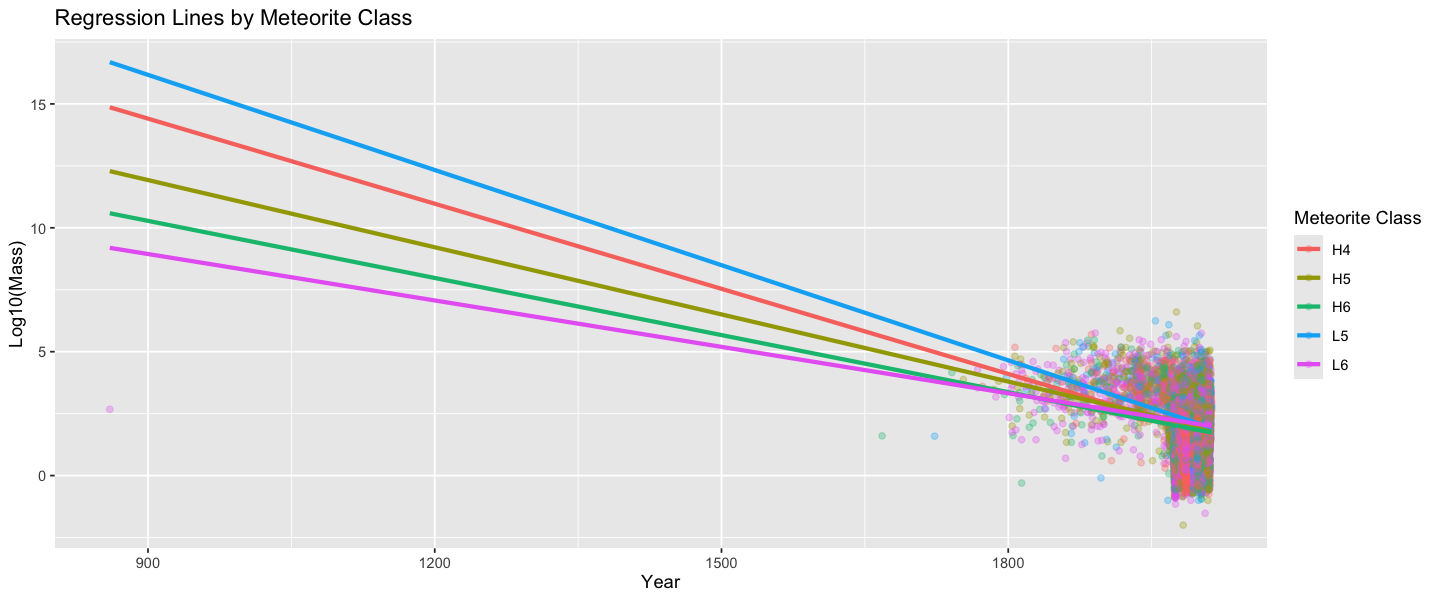

In [23]:
# Plot
options(repr.plot.width = 12, repr.plot.height = 5)

plot_classes <- ggplot(meteors_clean, aes(x = year, y = log_mass, color = recclass)) +
  geom_point(alpha = 0.3) +
  geom_line(
    data = prediction_grid,
    aes(x = year, y = pred_log_mass, color = recclass),
    linewidth = 1.2
  ) +
  labs(
    title = "Regression Lines by Meteorite Class",
    x = "Year",
    y = "Log10(Mass)",
    color = "Meteorite Class"
  )

plot_classes

**Interpretation of Figure 1**

Figure 1 shows a downward trend in predicted log₁₀(mass) over time across all major meteorite classes.

Key observations:

* All classes exhibit decreasing predicted mass over time.  
* The slopes differ slightly across classes, reflecting the interaction between year and meteorite classification.  
* Recent years show greater density of smaller-mass meteorites.

This pattern is consistent with improvements in detection technology over time, allowing smaller meteorites to be recorded in more recent periods.

**Figure 2\. Predicted vs Actual Log₁₀(Mass).**  
Scatterplot comparing predicted values from the regression model to actual observed log₁₀(mass) values. The red 45-degree line represents perfect prediction.

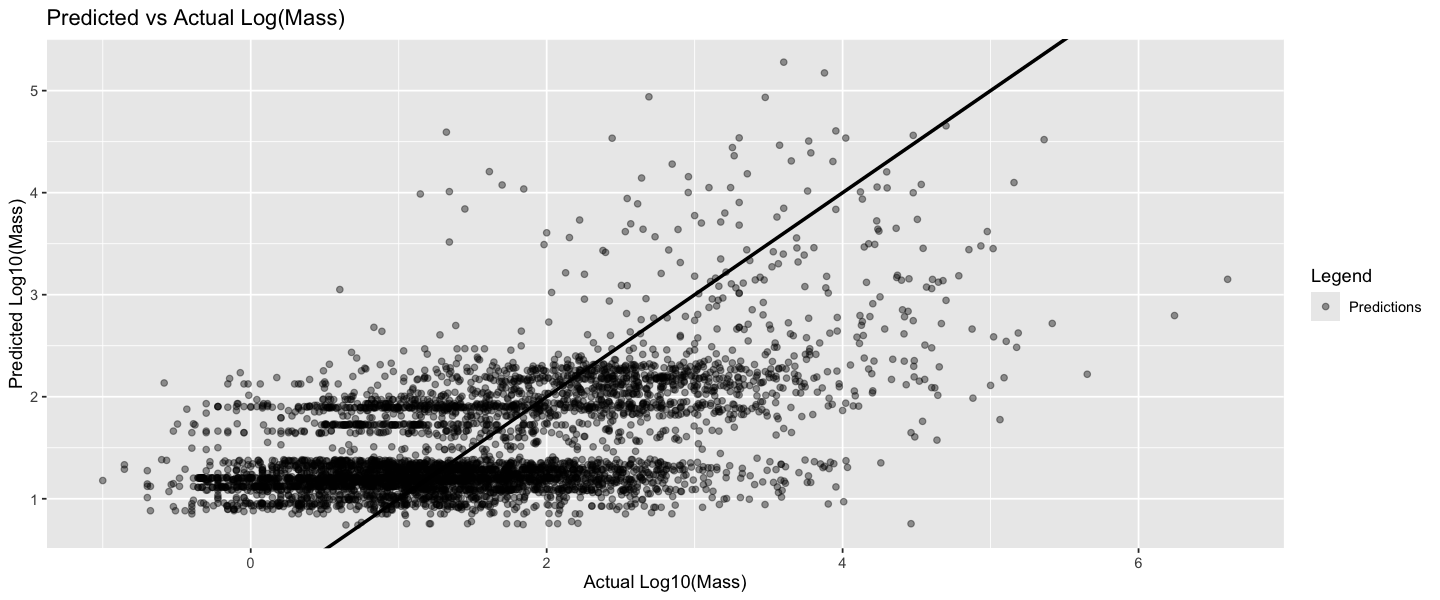

In [36]:
options(repr.plot.width = 12, repr.plot.height = 5)

plot_pred_vs_act <- ggplot(test_data, aes(x = log_mass, y = predictions)) +
  geom_point(aes(color = "Predictions"), alpha = 0.4) +
  geom_abline(intercept = 0, slope = 1, linewidth = 1) +
  scale_color_manual(
    name = "Legend",
    values = c("Predictions" = "black", "Perfect Fit" = "red")
  ) +
  labs(
    title = "Predicted vs Actual Log(Mass)",
    x = "Actual Log10(Mass)",
    y = "Predicted Log10(Mass)"
  )

plot_pred_vs_act


**Predictive Performance (Figure 2\)**

The predicted versus actual plot reveals:

* The model captures overall trends but does not perfectly align with the 45-degree reference line.  
* Predictions tend to be more concentrated than actual values, particularly for extreme masses.  
* Larger meteorites exhibit greater prediction variability.

Overall, the regression model explains systematic variation in meteorite mass but does not fully capture extreme outliers.

## **Results**

### **Temporal and Class Effects**

The regression results indicate:

* A statistically significant negative association between year and log₁₀(mass), suggesting that more recent meteorite observations tend to have lower recorded mass.  
* Significant interaction effects between year and several meteorite classes, indicating that the temporal trend in mass differs by classification.  
* Latitude and longitude were statistically significant predictors, suggesting spatial variation in recorded meteorite mass.  
* Fall status (Found vs Fell) was associated with systematic differences in log-mass.

### **Summary of Findings**

The analysis demonstrates that log-transformed meteorite mass is associated with temporal, geographic, and compositional characteristics. Temporal effects vary across meteorite classes, and geographic location contributes additional explanatory power. While the model captures general trends, predictive accuracy remains moderate, particularly for extreme values.
